In [205]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from arch import arch_model

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("ggplot")

In [206]:
# =============================================================================
# Repository paths
# =============================================================================

ROOT = Path("../..")

OUTPUT_DIR = ROOT / "output"

PREPROCESS_DIR = OUTPUT_DIR / "01_preprocessing"
DISTANCE_DIR   = OUTPUT_DIR / "03_distance"
CLUSTER_DIR    = OUTPUT_DIR / "04_clustering"

# Market prediction data
DATA_DIR = ROOT / "data" / "application_market_prediction"

In [207]:
# =============================================================================
# Load attention datasets
# =============================================================================

# Normalized panel (used for clustering)
panel = pd.read_csv(
    PREPROCESS_DIR / "panel_normalized.csv"
)

panel = panel.rename(columns={panel.columns[0]: "date"})
panel["date"] = pd.to_datetime(panel["date"])

# Raw panel (used for prediction)
panel_raw = pd.read_csv(
    PREPROCESS_DIR / "panel_raw_retained.csv"
)

panel_raw = panel_raw.rename(columns={panel_raw.columns[0]: "date"})
panel_raw["date"] = pd.to_datetime(panel_raw["date"])

clusters = pd.read_csv(
    CLUSTER_DIR / "final_cluster_assignments.csv"
)

# -------------------------------------------------------------------------
# Clean cluster assignments
# -------------------------------------------------------------------------

# Remove rows with missing search terms
clusters = clusters.dropna(subset=["term"]).copy()

# Standardise formatting
clusters["term"] = clusters["term"].astype(str).str.strip()
clusters["cluster"] = clusters["cluster"].astype(int)

mindist = pd.read_csv(
    DISTANCE_DIR / "sax_mindist_matrix_tiebroken.csv",
    index_col=0
)

print("Panel shape:      ", panel.shape)
print("Clusters shape:   ", clusters.shape)
print("MINDIST shape:    ", mindist.shape)

Panel shape:       (1612, 848)
Clusters shape:    (846, 2)
MINDIST shape:     (847, 847)


In [208]:
# =============================================================================
# Load Yahoo Finance csv
# =============================================================================

def load_market_csv(path):

    df = pd.read_csv(path)

    # Remove the ticker row
    df = df.iloc[2:].reset_index(drop=True)

    # Rename first column
    df.rename(columns={df.columns[0]: "date"}, inplace=True)

    # Convert types
    df["date"] = pd.to_datetime(df["date"])

    numeric_cols = [c for c in df.columns if c != "date"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [209]:
# =============================================================================
# Load market data
# =============================================================================

indices = {
    "S&P500": load_market_csv(DATA_DIR / "SP500 (1).csv"),
    "NASDAQ100": load_market_csv(DATA_DIR / "NASDAQ100.csv"),
    "DowJones": load_market_csv(DATA_DIR / "DOW.csv"),
    "Russell2000": load_market_csv(DATA_DIR / "RUSSELL2000.csv"),
}

for name, df in indices.items():
    print(name)
    print(df.head())
    print()

S&P500
        date        Close         High          Low         Open      Volume
0 2022-01-03  4796.560059  4796.640137  4758.169922  4778.140137  3831020000
1 2022-01-04  4793.540039  4818.620117  4774.270020  4804.509766  4683170000
2 2022-01-05  4700.580078  4797.700195  4699.439941  4787.990234  4887960000
3 2022-01-06  4696.049805  4725.009766  4671.259766  4693.390137  4295280000
4 2022-01-07  4677.029785  4707.950195  4662.740234  4697.660156  4181510000

NASDAQ100
        date         Close          High           Low          Open  \
0 2022-01-03  16501.769531  16504.140625  16306.639648  16395.509766   
1 2022-01-04  16279.730469  16513.869141  16151.900391  16513.869141   
2 2022-01-05  15771.780273  16249.230469  15763.839844  16190.549805   
3 2022-01-06  15765.360352  15900.599609  15608.570312  15675.219727   
4 2022-01-07  15592.190430  15835.000000  15526.799805  15774.129883   

       Volume  
0  4429960000  
1  5131110000  
2  5031850000  
3  4790820000  
4  4238

In [210]:
# =============================================================================
# Verify consistency
# =============================================================================

panel_terms = set(panel.columns[1:])
cluster_terms = set(clusters["term"])
mindist_terms = set(mindist.index)

print(f"Terms in panel:      {len(panel_terms)}")
print(f"Terms in clusters:   {len(cluster_terms)}")
print(f"Terms in MINDIST:    {len(mindist_terms)}")

print()

print("Panel == Clusters :", panel_terms == cluster_terms)
print("Panel == MINDIST  :", panel_terms == mindist_terms)
print("Clusters == MINDIST:", cluster_terms == mindist_terms)

Terms in panel:      847
Terms in clusters:   846
Terms in MINDIST:    847

Panel == Clusters : False
Panel == MINDIST  : False
Clusters == MINDIST: False


In [211]:
# =============================================================================
# Cluster summary
# =============================================================================

cluster_summary = (
    clusters["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="n_terms")
)

display(cluster_summary)

print()
print(f"Total clusters : {cluster_summary.shape[0]}")
print(f"Total terms    : {cluster_summary.n_terms.sum()}")

,cluster,n_terms
0,1,42
1,2,115
2,3,226
3,4,116
4,5,28
5,6,37
6,7,73
7,8,74
8,9,26
9,10,109



Total clusters : 10
Total terms    : 846


In [212]:
# =============================================================================
# Verify MINDIST matrix
# =============================================================================

print("Shape:", mindist.shape)

print()

print("Rows equal columns:",
      list(mindist.index) == list(mindist.columns))

print()

print("Symmetric:",
      np.allclose(mindist.values, mindist.values.T))

Shape: (847, 847)

Rows equal columns: False

Symmetric: True


In [213]:
# =============================================================================
# Terms belonging to each cluster
# =============================================================================

cluster_lookup = {}

for c in sorted(clusters.cluster.unique()):

    cluster_lookup[c] = (
        clusters.loc[
            clusters.cluster == c,
            "term"
        ].tolist()
    )

for c in cluster_lookup:

    print(f"Cluster {c}: {len(cluster_lookup[c])} terms")

Cluster 1: 42 terms
Cluster 2: 115 terms
Cluster 3: 226 terms
Cluster 4: 116 terms
Cluster 5: 28 terms
Cluster 6: 37 terms
Cluster 7: 73 terms
Cluster 8: 74 terms
Cluster 9: 26 terms
Cluster 10: 109 terms


In [214]:
# Missing terms
print(clusters["term"].isna().sum())

clusters[clusters["term"].isna()]

0


,term,cluster


In [215]:
# =============================================================================
# Rank terms inside each cluster
# =============================================================================

representative_rankings = {}

for cluster, terms in cluster_lookup.items():

    # MINDIST submatrix
    sub = mindist.loc[terms, terms]

    # Average distance to all other members
    mean_distance = sub.mean(axis=1)

    representative_rankings[cluster] = (
        mean_distance
        .sort_values()
        .reset_index()
        .rename(columns={
            "index": "term",
            0: "mean_distance"
        })
    )

In [216]:
# =============================================================================
# Construct cluster indices from raw search series
# =============================================================================

cluster_indices = {}

fractions = {
    "100%": 1.00,
    "75%": 0.75,
    "50%": 0.50,
    "25%": 0.25,
    "10%": 0.10,
}

for label, fraction in fractions.items():

    print(f"Building {label}...")

    cluster_indices[label] = build_cluster_indices(
        panel=panel_raw,                      # <-- changed
        representative_rankings=representative_rankings,
        fraction=fraction
    )

print("\nFinished!\n")

print(cluster_indices.keys())

Building 100%...
Building 75%...
Building 50%...
Building 25%...
Building 10%...

Finished!

dict_keys(['100%', '75%', '50%', '25%', '10%'])


In [217]:
# =============================================================================
# Convert attention indices to first differences
# =============================================================================

cluster_indices_diff = {}

for label, df in cluster_indices.items():

    temp = df.copy()

    cluster_cols = [c for c in temp.columns if c.startswith("cluster_")]

    temp[cluster_cols] = temp[cluster_cols].diff()

    temp = temp.dropna().reset_index(drop=True)

    cluster_indices_diff[label] = temp

print(cluster_indices_diff.keys())

dict_keys(['100%', '75%', '50%', '25%', '10%'])


In [218]:
# =============================================================================
# Prepare market datasets
# =============================================================================

market_data = {}

for name, df in indices.items():

    data = df.copy()

    # Yahoo column names
    close_col = "Close"

    data = data.sort_values("date")

    data["return"] = np.log(data[close_col]).diff()

    # Squared return as realised volatility proxy
    data["realized_volatility"] = data["return"] ** 2

    data = data.dropna().reset_index(drop=True)

    market_data[name] = data

    print(
        f"{name}:",
        len(data),
        "observations"
    )

S&P500: 1104 observations
NASDAQ100: 1104 observations
DowJones: 1104 observations
Russell2000: 1104 observations


In [219]:
# =============================================================================
# Merge attention indices with market data
# =============================================================================

merged_data = {}

for fraction, attention in cluster_indices_diff.items():

    merged_data[fraction] = {}

    for market, prices in market_data.items():

        merged = (
            prices.merge(
                attention,
                on="date",
                how="inner"
            )
            .sort_values("date")
            .reset_index(drop=True)
        )

        merged_data[fraction][market] = merged

        print(
            f"{market} ({fraction}) ->",
            merged.shape
        )

S&P500 (100%) -> (1104, 18)
NASDAQ100 (100%) -> (1104, 18)
DowJones (100%) -> (1104, 18)
Russell2000 (100%) -> (1104, 18)
S&P500 (75%) -> (1104, 18)
NASDAQ100 (75%) -> (1104, 18)
DowJones (75%) -> (1104, 18)
Russell2000 (75%) -> (1104, 18)
S&P500 (50%) -> (1104, 18)
NASDAQ100 (50%) -> (1104, 18)
DowJones (50%) -> (1104, 18)
Russell2000 (50%) -> (1104, 18)
S&P500 (25%) -> (1104, 18)
NASDAQ100 (25%) -> (1104, 18)
DowJones (25%) -> (1104, 18)
Russell2000 (25%) -> (1104, 18)
S&P500 (10%) -> (1104, 18)
NASDAQ100 (10%) -> (1104, 18)
DowJones (10%) -> (1104, 18)
Russell2000 (10%) -> (1104, 18)


In [220]:
merged_data["100%"]["S&P500"].head()

,date,Close,High,Low,Open,Volume,return,realized_volatility,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10
0,2022-01-04,4793.540039,4818.620117,4774.270020,4804.509766,4683170000,-0.000630,3.966736e-07,2.380952,5.956522,3.778761,6.060345,2.214286,2.594595,-2.315068,3.297297,1.076923,3.871560
1,2022-01-05,4700.580078,4797.700195,4699.439941,4787.990234,4887960000,-0.019583,3.835042e-04,0.357143,1.000000,-1.668142,-2.784483,1.642857,-2.405405,-6.287671,-4.662162,-0.923077,-4.256881
2,2022-01-06,4696.049805,4725.009766,4671.259766,4693.390137,4295280000,-0.000964,9.297467e-07,-1.000000,-3.582609,-5.986726,-4.422414,0.000000,-1.189189,-2.739726,-9.675676,-0.461538,-3.330275
3,2022-01-07,4677.029785,4707.950195,4662.740234,4697.660156,4181510000,-0.004058,1.647094e-05,0.547619,1.556522,4.261062,3.086207,-1.714286,2.027027,1.849315,7.527027,0.730769,4.064220
4,2022-01-10,4670.290039,4673.020020,4582.240234,4655.339844,4511810000,-0.001442,2.079567e-06,0.404762,8.617391,4.269912,7.663793,-6.285714,1.756757,-9.958904,-7.567568,-0.461538,-8.422018


In [221]:
merged_data["100%"]["S&P500"].filter(regex="cluster").describe()

,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10
count,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000,1104.000000
mean,-0.487470,3.871361,0.957854,1.664393,-0.974011,0.036171,-1.864702,-0.982938,-1.704731,-1.208472
std,4.148760,11.597830,6.915795,6.185618,8.930221,221.360700,5.701085,6.490666,8.818385,4.262536
min,-26.176130,-148.142872,-86.471019,-52.633708,-130.546185,-6114.173110,-34.440411,-36.955205,-95.281006,-24.450482
25%,-1.626001,-0.568634,-1.046005,-1.030356,-0.587142,-2.000000,-2.116417,-2.541575,-2.765701,-2.413242
50%,-0.128962,0.909177,0.183861,0.504310,-0.013220,0.129066,-0.219432,-0.187773,-0.115385,-0.228099
75%,1.161960,3.873320,2.847182,4.247252,0.417911,2.519451,0.342466,1.171697,1.429283,1.028332
max,24.840105,163.190879,95.926410,54.192861,44.050553,3590.608388,46.270054,83.929454,54.543779,39.204399


In [222]:
# =============================================================================
# Create lagged attention datasets
# =============================================================================

cluster_cols = [c for c in merged_data["100%"]["S&P500"].columns
                if c.startswith("cluster_")]

lagged_data = {}

for lag in [0, 1, 2]:

    lagged_data[lag] = {}

    for fraction, markets in merged_data.items():

        lagged_data[lag][fraction] = {}

        for market, df in markets.items():

            temp = df.copy()

            temp[cluster_cols] = temp[cluster_cols].shift(lag)

            temp = temp.dropna().reset_index(drop=True)

            lagged_data[lag][fraction][market] = temp

print("Lagged datasets created.")

Lagged datasets created.


In [223]:
# =============================================================================
# Train/test split
# =============================================================================

train_fraction = 0.8

datasets = {}

for lag, lag_dict in lagged_data.items():

    datasets[lag] = {}

    for fraction, markets in lag_dict.items():

        datasets[lag][fraction] = {}

        for market, df in markets.items():

            split = int(len(df) * train_fraction)

            datasets[lag][fraction][market] = {
                "train": df.iloc[:split].copy(),
                "test": df.iloc[split:].copy()
            }

print("Train/test datasets created.")

Train/test datasets created.


In [224]:
# =============================================================================
# Baseline GARCH(1,1): Rolling one-step-ahead forecasts
# =============================================================================

from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd


def baseline_garch_forecast(df,
                            train_fraction=0.8,
                            p=1,
                            q=1):

    returns = df["return"].dropna() * 100  # percentage returns
    target = df.loc[returns.index, "realized_volatility"]

    split = int(len(returns) * train_fraction)

    train_returns = returns.iloc[:split]
    test_returns = returns.iloc[split:]
    test_target = target.iloc[split:]

    forecasts = []

    history = train_returns.copy()

    for r in test_returns:

        model = arch_model(
            history,
            mean="Constant",
            vol="GARCH",
            p=p,
            q=q,
            dist="normal"
        )

        res = model.fit(disp="off")

        forecast = res.forecast(horizon=1)

        variance = forecast.variance.iloc[-1, 0]

        forecasts.append(variance / (100**2))  # convert back to decimal returns

        history = pd.concat([history, pd.Series([r])], ignore_index=True)

    rmse = np.sqrt(mean_squared_error(test_target, forecasts))
    mae = mean_absolute_error(test_target, forecasts)

    return {
        "forecast": forecasts,
        "actual": test_target.values,
        "rmse": rmse,
        "mae": mae
    }

In [225]:
baseline_results = baseline_garch_forecast(
    lagged_data[1]["100%"]["S&P500"]
)

print(f"RMSE: {baseline_results['rmse']:.6f}")
print(f"MAE : {baseline_results['mae']:.6f}")

RMSE: 0.000109
MAE : 0.000068


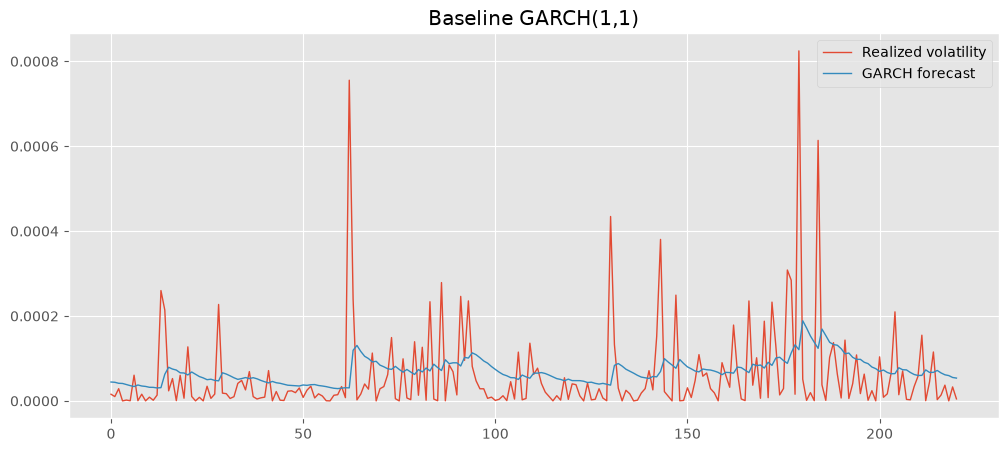

In [226]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    baseline_results["actual"],
    label="Realized volatility",
    linewidth=1
)

plt.plot(
    baseline_results["forecast"],
    label="GARCH forecast",
    linewidth=1
)

plt.legend()
plt.title("Baseline GARCH(1,1)")
plt.show()

In [227]:
ss_res = np.sum(
    (baseline_results["actual"] - baseline_results["forecast"])**2
)

ss_tot = np.sum(
    (baseline_results["actual"] - baseline_results["actual"].mean())**2
)

r2_oos = 1 - ss_res / ss_tot

print(f"Out-of-sample R²: {r2_oos:.4f}")

Out-of-sample R²: -0.0125


In [228]:
# =============================================================================
# Baseline GARCH forecast errors
# =============================================================================

results_df = pd.DataFrame({
    "actual_volatility": baseline_results["actual"],
    "forecast_volatility": baseline_results["forecast"]
})

results_df["forecast_error"] = (
    results_df["actual_volatility"] -
    results_df["forecast_volatility"]
)

results_df["absolute_error"] = (
    results_df["forecast_error"].abs()
)

results_df.head()

,actual_volatility,forecast_volatility,forecast_error,absolute_error
0,1.571445e-05,0.000044,-0.000029,0.000029
1,1.016697e-05,0.000044,-0.000034,0.000034
2,2.872296e-05,0.000041,-0.000013,0.000013
3,8.188495e-09,0.000041,-0.000041,0.000041
4,1.954843e-06,0.000038,-0.000036,0.000036


In [229]:
# =============================================================================
# Attach attention variables
# =============================================================================

df = lagged_data[1]["100%"]["S&P500"].copy()

split = int(len(df) * 0.8)

test_df = df.iloc[split:].reset_index(drop=True)

cluster_cols = [
    c for c in test_df.columns
    if c.startswith("cluster_")
]

analysis_df = pd.concat(
    [
        test_df[["date"] + cluster_cols],
        results_df
    ],
    axis=1
)

analysis_df.head()

,date,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10,actual_volatility,forecast_volatility,forecast_error,absolute_error
0,2025-07-15,-2.066009,4.323491,8.318483,13.133974,0.125043,0.297786,-0.531204,-7.296472,-19.455298,-4.681474,1.571445e-05,0.000044,-0.000029,0.000029
1,2025-07-16,-0.573264,1.479513,-0.803780,-4.348017,-0.149331,-0.113782,-0.534335,-0.273526,-6.013802,-1.358678,1.016697e-05,0.000044,-0.000034,0.000034
2,2025-07-17,0.179431,-1.293824,-1.731035,0.691475,0.377325,0.806281,0.286852,0.099054,1.901665,-0.425204,2.872296e-05,0.000041,-0.000013,0.000013
3,2025-07-18,1.215658,0.803201,3.055678,12.480610,-0.092833,5.579308,0.270736,3.987089,-4.019382,3.348231,8.188495e-09,0.000041,-0.000041,0.000041
4,2025-07-21,-1.219527,-2.251724,-5.841214,-1.134801,-0.116231,-5.354049,-0.579093,-0.478260,5.510249,-2.448265,1.954843e-06,0.000038,-0.000036,0.000036


In [230]:
# =============================================================================
# Largest underpredictions
# =============================================================================

threshold = analysis_df["forecast_error"].quantile(0.95)

analysis_df["large_underprediction"] = (
    analysis_df["forecast_error"] >= threshold
)

print(
    analysis_df["large_underprediction"].value_counts()
)

large_underprediction
False    209
True      12
Name: count, dtype: int64


In [231]:
# =============================================================================
# Mean attention during GARCH failures
# =============================================================================

comparison = pd.DataFrame({
    "Normal days":
        analysis_df.loc[
            ~analysis_df["large_underprediction"],
            cluster_cols
        ].mean(),

    "Large underpredictions":
        analysis_df.loc[
            analysis_df["large_underprediction"],
            cluster_cols
        ].mean()
})

comparison["Difference"] = (
    comparison["Large underpredictions"] -
    comparison["Normal days"]
)

comparison.sort_values(
    "Difference",
    ascending=False
)

,Normal days,Large underpredictions,Difference
cluster_9,-2.229896,1.653180,3.883076
cluster_7,-2.495285,-0.684564,1.810721
cluster_8,-0.982048,-0.192493,0.789555
cluster_10,-1.188790,-0.635052,0.553738
cluster_6,0.030433,0.426167,0.395735
cluster_4,1.914207,2.303762,0.389555
cluster_1,-0.370792,-0.115834,0.254959
cluster_3,1.099004,1.125515,0.026512
cluster_2,4.687386,1.676608,-3.010778
cluster_5,-1.095892,-6.526525,-5.430633


In [232]:
from scipy.stats import mannwhitneyu

results = []

for col in cluster_cols:

    normal = analysis_df.loc[
        ~analysis_df["large_underprediction"],
        col
    ]

    shock = analysis_df.loc[
        analysis_df["large_underprediction"],
        col
    ]

    stat, p = mannwhitneyu(
        shock,
        normal,
        alternative="two-sided"
    )

    results.append({
        "cluster": col,
        "p_value": p,
        "median_normal": normal.median(),
        "median_underprediction": shock.median(),
        "difference": shock.median() - normal.median()
    })

mw_results = (
    pd.DataFrame(results)
      .sort_values("p_value")
)

mw_results

,cluster,p_value,median_normal,median_underprediction,difference
8,cluster_9,0.150761,-0.129245,1.822212,1.951457
6,cluster_7,0.337724,-0.467067,0.245427,0.712494
1,cluster_2,0.340068,1.367574,0.506851,-0.860723
7,cluster_8,0.386587,-0.097678,0.844013,0.941691
4,cluster_5,0.484743,-0.073642,0.095626,0.169268
9,cluster_10,0.572712,-0.224526,0.369680,0.594206
5,cluster_6,0.611207,0.115030,0.483394,0.368364
2,cluster_3,0.677774,0.536888,-0.090257,-0.627145
3,cluster_4,0.876409,0.769715,0.811528,0.041813
0,cluster_1,0.931557,-0.084311,-0.172293,-0.087983


In [233]:
# =============================================================================
# Reconstruct the test dataframe
# =============================================================================

test = lagged_data[1]["100%"]["S&P500"].copy()

split = int(len(test) * 0.8)

test = test.iloc[split:].reset_index(drop=True)

test["forecast"] = baseline_results["forecast"]
test["actual"] = baseline_results["actual"]

test["forecast_error"] = (
    test["actual"] -
    test["forecast"]
)

# Define GARCH failures
threshold = test["forecast_error"].quantile(0.95)

test["garch_failure"] = (
    test["forecast_error"] >= threshold
).astype(int)

test.head()

,date,Close,High,Low,Open,Volume,return,realized_volatility,cluster_1,cluster_2,...,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_10,forecast,actual,forecast_error,garch_failure
0,2025-07-15,6243.759766,6302.040039,6241.680176,6295.290039,5133670000,-0.003964,1.571445e-05,-2.066009,4.323491,...,0.125043,0.297786,-0.531204,-7.296472,-19.455298,-4.681474,0.000044,1.571445e-05,-0.000029,0
1,2025-07-16,6263.700195,6268.120117,6201.589844,6254.500000,5177460000,0.003189,1.016697e-05,-0.573264,1.479513,...,-0.149331,-0.113782,-0.534335,-0.273526,-6.013802,-1.358678,0.000044,1.016697e-05,-0.000034,0
2,2025-07-17,6297.359863,6304.689941,6262.270020,6263.399902,5512290000,0.005359,2.872296e-05,0.179431,-1.293824,...,0.377325,0.806281,0.286852,0.099054,1.901665,-0.425204,0.000041,2.872296e-05,-0.000013,0
3,2025-07-18,6296.790039,6315.609863,6285.270020,6312.950195,5184700000,-0.000090,8.188495e-09,1.215658,0.803201,...,-0.092833,5.579308,0.270736,3.987089,-4.019382,3.348231,0.000041,8.188495e-09,-0.000041,0
4,2025-07-21,6305.600098,6336.080078,6303.790039,6304.740234,5010840000,0.001398,1.954843e-06,-1.219527,-2.251724,...,-0.116231,-5.354049,-0.579093,-0.478260,5.510249,-2.448265,0.000038,1.954843e-06,-0.000036,0


In [234]:
# =============================================================================
# Cluster behaviour before GARCH failures
# =============================================================================

import numpy as np

cluster = "cluster_9"
window = 5

failure_days = test.index[
    test["garch_failure"] == 1
]

profiles = []

for day in failure_days:

    if day >= window:

        profile = test.loc[
            day-window:day,
            cluster
        ].values

        profiles.append(profile)

profiles = np.array(profiles)

print(f"Number of GARCH failures used: {len(profiles)}")

Number of GARCH failures used: 12


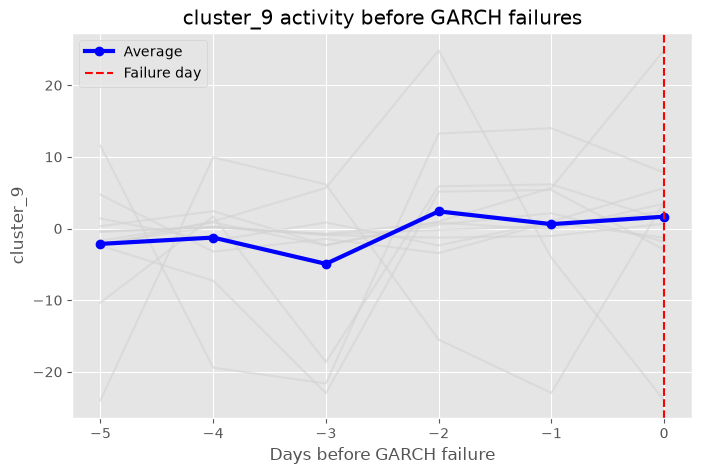

In [235]:
# =============================================================================
# Plot all profiles + average
# =============================================================================

import matplotlib.pyplot as plt

days = np.arange(-window, 1)

plt.figure(figsize=(8,5))

# Individual failures
for profile in profiles:
    plt.plot(days, profile,
             color="lightgray",
             alpha=0.6)

# Mean profile
mean_profile = profiles.mean(axis=0)

plt.plot(
    days,
    mean_profile,
    color="blue",
    linewidth=3,
    marker="o",
    label="Average"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Failure day"
)

plt.xlabel("Days before GARCH failure")
plt.ylabel(cluster)
plt.title(f"{cluster} activity before GARCH failures")

plt.legend()
plt.grid(True)

plt.show()

In [236]:
# =============================================================================
# Show the largest GARCH failures
# =============================================================================

failures = test.loc[
    test["garch_failure"] == 1,
    [
        "date",
        "forecast",
        "actual",
        "forecast_error"
    ]
]

failures.sort_values(
    "forecast_error",
    ascending=False
)

,date,forecast,actual,forecast_error
62,2025-10-10,0.000031,0.000755,0.000725
179,2026-03-31,0.000121,0.000825,0.000704
184,2026-04-08,0.000124,0.000614,0.000490
130,2026-01-20,0.000037,0.000434,0.000397
143,2026-02-06,0.000069,0.000380,0.000311
13,2025-08-01,0.000031,0.000260,0.000229
176,2026-03-26,0.000088,0.000308,0.000220
86,2025-11-13,0.000072,0.000279,0.000207
28,2025-08-22,0.000047,0.000227,0.000180
147,2026-02-12,0.000077,0.000249,0.000172


In [237]:
failure_days = failures.index.tolist()

for d in failure_days:

    print("="*70)

    print(test.loc[d,
        ["date","forecast","actual","forecast_error"]
    ])

date              2025-08-01 00:00:00
forecast                     0.000031
actual                        0.00026
forecast_error               0.000229
Name: 13, dtype: object
date              2025-08-22 00:00:00
forecast                     0.000047
actual                       0.000227
forecast_error                0.00018
Name: 28, dtype: object
date              2025-10-10 00:00:00
forecast                     0.000031
actual                       0.000755
forecast_error               0.000725
Name: 62, dtype: object
date              2025-11-13 00:00:00
forecast                     0.000072
actual                       0.000279
forecast_error               0.000207
Name: 86, dtype: object
date              2026-01-20 00:00:00
forecast                     0.000037
actual                       0.000434
forecast_error               0.000397
Name: 130, dtype: object
date              2026-02-06 00:00:00
forecast                     0.000069
actual                        0.00038
forec

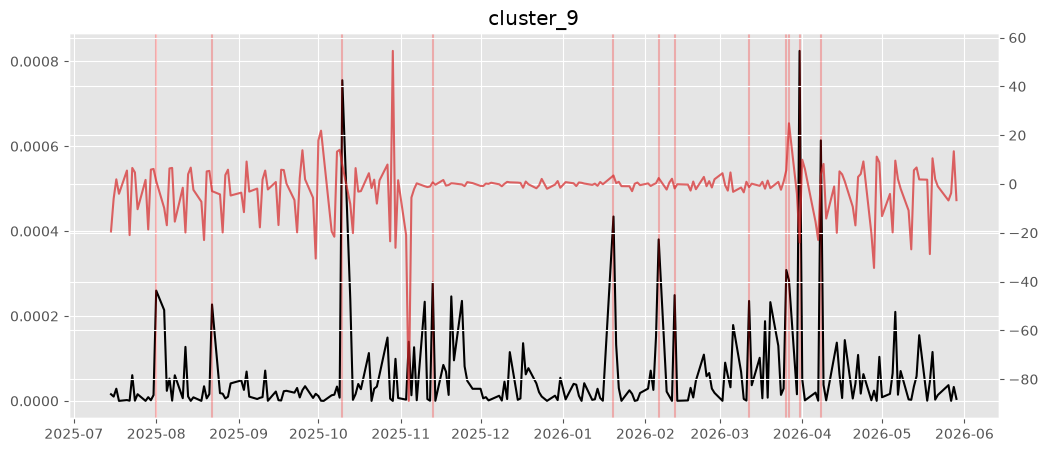

In [238]:
import matplotlib.pyplot as plt

cluster = "cluster_9"

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    test["date"],
    test["actual"],
    color="black",
    label="Realized volatility"
)

ax2 = ax1.twinx()

ax2.plot(
    test["date"],
    test[cluster],
    color="tab:red",
    alpha=0.7,
    label=cluster
)

for d in failures["date"]:
    ax1.axvline(
        d,
        color="red",
        alpha=0.25
    )

plt.title(cluster)

plt.show()

In [239]:
# =============================================================================
# Centroid cluster indices (single most representative term)
# =============================================================================

centroid_indices = pd.DataFrame()
centroid_indices["date"] = panel_raw["date"]

for cluster in sorted(representative_rankings.keys()):

    centroid = representative_rankings[cluster].iloc[0]["term"]

    centroid_indices[f"cluster_{cluster}"] = panel_raw[centroid]

In [240]:
cluster_cols = [
    c for c in centroid_indices.columns
    if c.startswith("cluster_")
]

centroid_indices[cluster_cols] = (
    centroid_indices[cluster_cols]
    .shift(1)
)

centroid_indices = (
    centroid_indices
    .dropna()
    .reset_index(drop=True)
)

In [241]:
centroid_data = (
    market_data["S&P500"]
    .merge(
        centroid_indices,
        on="date",
        how="inner"
    )
    .sort_values("date")
    .reset_index(drop=True)
)

In [242]:
split = int(len(centroid_data) * 0.8)

train = centroid_data.iloc[:split]
test = centroid_data.iloc[split:].reset_index(drop=True)

In [243]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# -------------------------------------------------------
# Build train/test matrices
# -------------------------------------------------------

cluster_cols = [c for c in train.columns if c.startswith("cluster_")]

# GARCH forecasts
garch_train = baseline_train_forecasts.reshape(-1, 1)
garch_test = baseline_results["forecast"].reshape(-1, 1)

# Combine GARCH + centroid indices
X_train = np.column_stack([
    garch_train,
    train[cluster_cols].values
])

X_test = np.column_stack([
    garch_test,
    test[cluster_cols].values
])

y_train = train["realized_volatility"].values
y_test = test["realized_volatility"].values

# -------------------------------------------------------
# Fit model
# -------------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

# -------------------------------------------------------
# Evaluation
# -------------------------------------------------------

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

ss_res = np.sum((y_test - pred) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Enhanced RMSE : {rmse:.4f}")
print(f"Enhanced MAE  : {mae:.4f}")
print(f"Enhanced OOS R² : {r2:.4f}")

NameError: name 'baseline_train_forecasts' is not defined